In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from IPython.display import display

current_dir = os.path.abspath('')
src_path = os.path.abspath(os.path.join(current_dir, '..', 'src'))

if not os.path.exists(src_path):
    src_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src'))

if not os.path.exists(src_path):
    raise FileNotFoundError(f"CRÍTICO: No se pudo encontrar la carpeta 'src'. Python la buscó en: {src_path}")

if src_path not in sys.path:
    sys.path.append(src_path)

print(f"Ruta de origen de módulos resuelta exitosamente: {src_path}")

import pathmnist_eda 

from pathmnist_eda import (
    PathMNISTLoader, DistributionAnalyzer, RGBAnalyzer, 
    IntegrityAuditor, FeatureExplorer, EDAVisualizer
)

print(f"El módulo se está leyendo físicamente desde: {pathmnist_eda.__file__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ruta de origen de módulos resuelta exitosamente: c:\Users\dcarr\repos\pathmnist-medical-vision-ml\src
El módulo se está leyendo físicamente desde: c:\Users\dcarr\repos\pathmnist-medical-vision-ml\src\pathmnist_eda.py


# FASE 1 & 2: Carga Oficial y Auditoría Estructural

In [3]:
print("--- FASE 1 & 2: Carga y Estructura ---")
loader = PathMNISTLoader()
datasets, class_id_to_name = loader.load_data(download=True)

display(loader.get_metadata())
display(loader.audit_structure())

--- FASE 1 & 2: Carga y Estructura ---


,Atributo,Valor
0,Dataset,PathMNIST
1,Identificador,pathmnist
2,Tarea,multi-class
3,Canales,3
4,Clases,9


,split,num_images,shape,label_shape,pixel_min,pixel_max
0,train,89996,"(28, 28, 3)","(89996, 1)",0,255
1,validation,10004,"(28, 28, 3)","(10004, 1)",0,255
2,test,7180,"(28, 28, 3)","(7180, 1)",0,255


# FASE 3 & 7: Distribución de Clases y Shift (Jensen-Shannon)

In [4]:
print("\n--- FASE 3: Distribución de Clases ---")
dist_analyzer = DistributionAnalyzer(datasets, class_id_to_name)
dist_df = dist_analyzer.get_class_distribution()


--- FASE 3: Distribución de Clases ---


# Resumen porcentual pivotado

split,test,train,validation
class_name,,,
adipose,18.64,10.41,10.41
background,11.80,10.57,10.57
cancer-associated stroma,5.86,10.45,10.45
colorectal adenocarcinoma epithelium,17.17,14.32,14.31
debris,4.72,11.51,11.52
lymphocytes,8.83,11.56,11.56
mucus,14.42,8.90,8.90
normal colon mucosa,10.32,8.76,8.77
smooth muscle,8.25,13.54,13.53


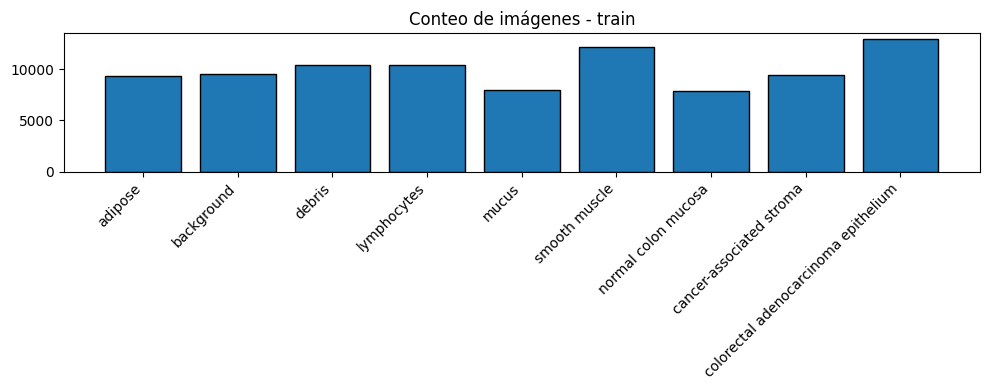


--- FASE 7: Divergencia Jensen-Shannon ---


,comparison,channel,jensen_shannon_divergence
0,validation_vs_train,R,0.000195
1,validation_vs_train,G,0.000230
2,validation_vs_train,B,0.000221
3,test_vs_train,R,0.056287
4,test_vs_train,G,0.053513
5,test_vs_train,B,0.056842


In [5]:
porcentajes_df = dist_df.pivot(index="class_name", columns="split", values="percentage").round(2)
display(porcentajes_df)
EDAVisualizer.plot_class_counts(dist_df, "train")

print("\n--- FASE 7: Divergencia Jensen-Shannon ---")
try:
    js_df = dist_analyzer.get_jensen_shannon_divergence()
    display(js_df)
except AttributeError:
    print("CRÍTICO: No has implementado el método 'get_jensen_shannon_divergence' en la clase DistributionAnalyzer.")


# FASE 5: Estadísticas RGB y Normalización

In [6]:
print("\n--- FASE 5: Estadísticas RGB Globales ---")
rgb_analyzer = RGBAnalyzer(datasets, class_id_to_name)
print("Parámetros recomendados de normalización (estrictamente desde train):")
display(rgb_analyzer.get_normalization_params())


--- FASE 5: Estadísticas RGB Globales ---
Parámetros recomendados de normalización (estrictamente desde train):


,channel,mean_0_1,std_0_1
0,R,0.7405,0.1237
1,G,0.5330,0.1768
2,B,0.7058,0.1244


# FASE 8 & 9: Auditoría de Calidad Visual y Leakage (Duplicados)

In [7]:

print("\n--- FASE 8: Auditoría de Calidad Visual ---")
auditor = IntegrityAuditor(datasets, class_id_to_name)

try:
    quality_df, thresholds = auditor.audit_visual_quality()
    print("Umbrales exploratorios calculados:")
    display(pd.DataFrame([thresholds]).round(3))
    
    print("Imágenes con flags visuales por split:")
    flags_resumen = quality_df.groupby("split")[["num_flags"]].sum().reset_index()
    display(flags_resumen)
except AttributeError:
    print("CRÍTICO: No has implementado el método 'audit_visual_quality' en la clase IntegrityAuditor.")

print("\n--- FASE 9: Detección de Fuga de Datos (Leakage) ---")
hash_df, duplicates_df = auditor.detect_duplicates()
print(f"Total de imágenes evaluadas por hash MD5: {len(hash_df)}")
print(f"Imágenes con hashes duplicados detectadas: {len(duplicates_df)}")
if len(duplicates_df) > 0:
    print("ADVERTENCIA: Revisa 'duplicates_df' para confirmar si los duplicados cruzan splits de entrenamiento y evaluación.")


--- FASE 8: Auditoría de Calidad Visual ---
Umbrales exploratorios calculados:


,very_dark_mean,very_bright_mean,very_low_std,very_high_std
0,96.465,231.298,0.921,46.761


Imágenes con flags visuales por split:


,split,num_flags
0,test,277
1,train,3631
2,validation,381



--- FASE 9: Detección de Fuga de Datos (Leakage) ---
Total de imágenes evaluadas por hash MD5: 107180
Imágenes con hashes duplicados detectadas: 0


# FASE 10: Exploración de Atributos (PCA)


--- FASE 10: Separabilidad Preliminar PCA ---
Varianza explicada por componentes (PC1, PC2): [0.5475 0.0239]


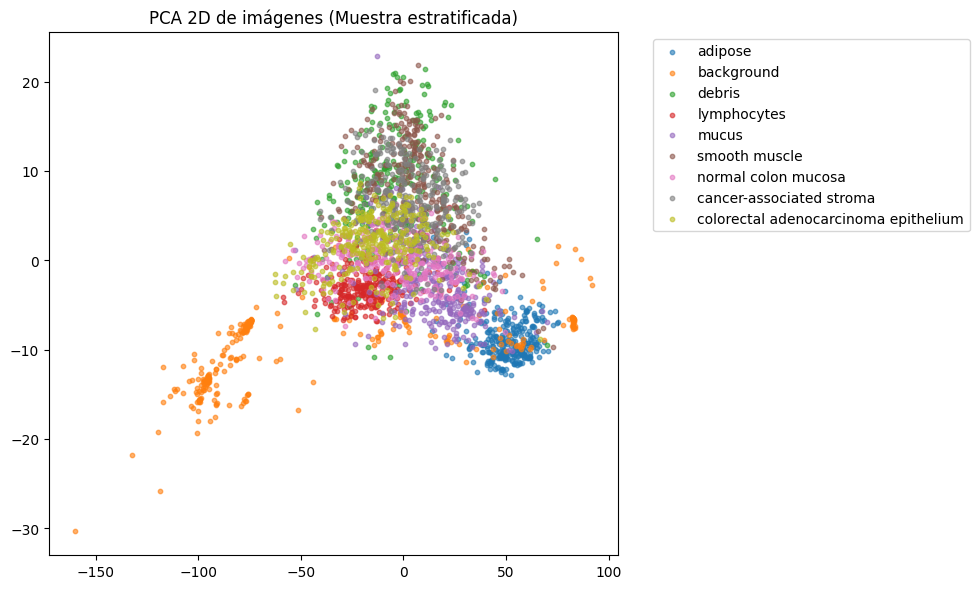

In [8]:
print("\n--- FASE 10: Separabilidad Preliminar PCA ---")
pca_explorer = FeatureExplorer(datasets, class_id_to_name)
pca_df, variance_ratio = pca_explorer.build_pca_projection(split_name="train", samples_per_class=300)

print(f"Varianza explicada por componentes (PC1, PC2): {np.round(variance_ratio, 4)}")
EDAVisualizer.plot_pca_projection(pca_df)